In [1]:
# pip install numpy matplotlib pandas scikit-learn geopandas scipy anndata

# Preliminaries

## Import library

In [2]:
import epsbasin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.tri import Triangulation
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import geopandas as gpd
from scipy.spatial import Delaunay
from scipy.spatial import cKDTree
import anndata
from collections import OrderedDict
from matplotlib.lines import Line2D
import os
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## File path

In [3]:
DATA_DIR = "data"
DATA_NAME = "Typhoon/Tracks.2022-08.MEARI.csv"
# OUTPUT_DIR = "Figure_source"

## Read input data

In [4]:
df_input = pd.read_csv(f"{DATA_DIR}/{DATA_NAME}", header=0, sep=";", skiprows=0)
df_input

,InitializationTime,ForecastTime,Horizon,Member,type,lon,lat,X,Y,prmsl,X1,Y1,Xs,Ys,id1,id2
0,2022-08-09 12:00:00,2022-08-09 12:00:00,0,0,Unperturbed,142.18,24.69,1.227580e+06,2.749742e+06,100888.304688,0.000000,0.000000,3.102392,-1.525439,20220809120000_20220809133000_00,01_01_00
1,2022-08-09 12:00:00,2022-08-09 15:00:00,3,0,Unperturbed,141.69,25.44,1.173638e+06,2.830610e+06,100738.375000,-0.230875,0.700910,2.796171,-1.298818,20220809120000_20220809163000_00,01_02_00
2,2022-08-09 12:00:00,2022-08-09 18:00:00,6,0,Unperturbed,140.67,24.82,1.073605e+06,2.756954e+06,100664.265625,-0.659018,0.062509,2.228303,-1.505228,20220809120000_20220809193000_00,01_03_00
3,2022-08-09 12:00:00,2022-08-09 21:00:00,9,0,Unperturbed,140.35,25.71,1.037221e+06,2.854463e+06,100722.023438,-0.814743,0.907655,2.021758,-1.231972,20220809120000_20220809223000_00,01_04_00
4,2022-08-09 12:00:00,2022-08-10 00:00:00,12,0,Unperturbed,140.05,25.51,1.007895e+06,2.831085e+06,100734.101562,-0.940259,0.705031,1.855279,-1.297486,20220809120000_20220810013000_00,01_05_00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3817,2022-08-12 12:00:00,2022-08-13 15:00:00,27,20,Perturbed,140.51,36.75,9.920775e+05,4.081313e+06,100269.929688,-0.947002,4.653192,1.765487,2.206112,20220812120000_20220813163000_20,13_10_20
3818,2022-08-12 12:00:00,2022-08-13 18:00:00,30,20,Perturbed,142.00,37.58,1.118470e+06,4.182326e+06,99956.609375,-0.438763,5.006179,2.482991,2.489189,20220812120000_20220813193000_20,13_11_20
3819,2022-08-12 12:00:00,2022-08-13 21:00:00,33,20,Perturbed,143.35,38.40,1.229691e+06,4.283352e+06,99821.304688,0.008474,5.359212,3.114376,2.772301,20220812120000_20220813223000_20,13_12_20
3820,2022-08-12 12:00:00,2022-08-14 00:00:00,36,20,Perturbed,144.53,39.07,1.325190e+06,4.368027e+06,99828.367188,0.392489,5.655105,3.656507,3.009592,20220812120000_20220814013000_20,13_13_20


In [5]:
print("Start InitializationTime\t%s" % df_input["InitializationTime"].loc[0])
print("End InitializationTime\t%s" % df_input["InitializationTime"].values[-1])
print("#InitializationTime\t%d" % len(np.unique(df_input["InitializationTime"].values)))
print("#ForecastTime\t%d" % len(np.unique(df_input["ForecastTime"].values)))
print("#Ensemble\t%d" % len(np.unique(df_input["Member"].values)))

Start InitializationTime	2022-08-09 12:00:00
End InitializationTime	2022-08-12 12:00:00
#InitializationTime	13
#ForecastTime	38
#Ensemble	21


## Construct anndata

In [6]:
adata = anndata.AnnData(
    df_input[['lon', 'lat']].values,
    obs=df_input,
    uns={'cost_matrix': pairwise_distances(df_input[['lon', 'lat']].values)}
)
adata

AnnData object with n_obs × n_vars = 3822 × 2
    obs: 'InitializationTime', 'ForecastTime', 'Horizon', 'Member', 'type', 'lon', 'lat', 'X', 'Y', 'prmsl', 'X1', 'Y1', 'Xs', 'Ys', 'id1', 'id2'
    uns: 'cost_matrix'

## Set index of sequence

In [7]:
df_input_tmp = df_input.set_index(['InitializationTime', 'Member'])
adata.obs['seq_id'] = pd.factorize(df_input_tmp.index)[0]

## Read best track data

In [8]:
best_track_df = pd.read_csv(f"{DATA_DIR}/Typhoon/Best.Track.2022-08.MEARI.csv", header=0, sep=",")

## Read background geographic data

In [9]:
background = gpd.read_file(f"{DATA_DIR}/geopandas/ne_110m_admin_0_countries.shp")

## Set ensamble colors

In [10]:
ensamble_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
            '#ffff33', '#a65628', '#f781bf', '#999999', '#66c2a5',
            '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f',
            '#e5c494', '#b3b3b3', '#1f78b4', '#33a02c', '#fb9a99', '#cab2d6']

## Visualization of Input Data

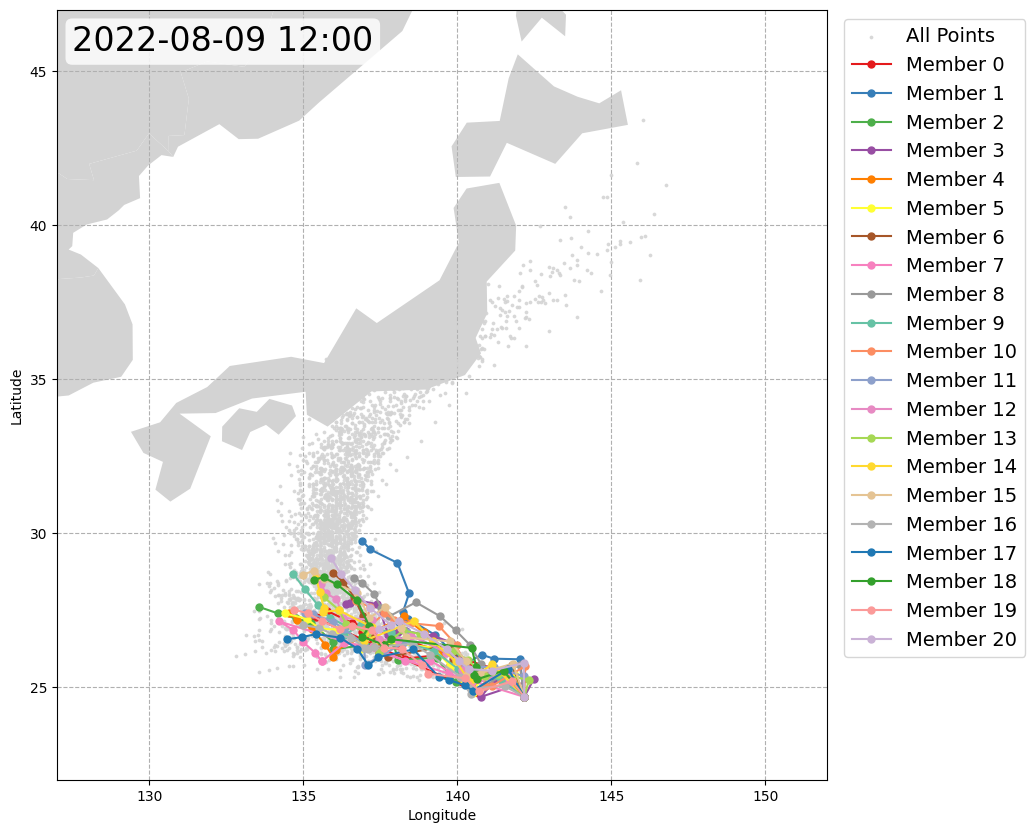

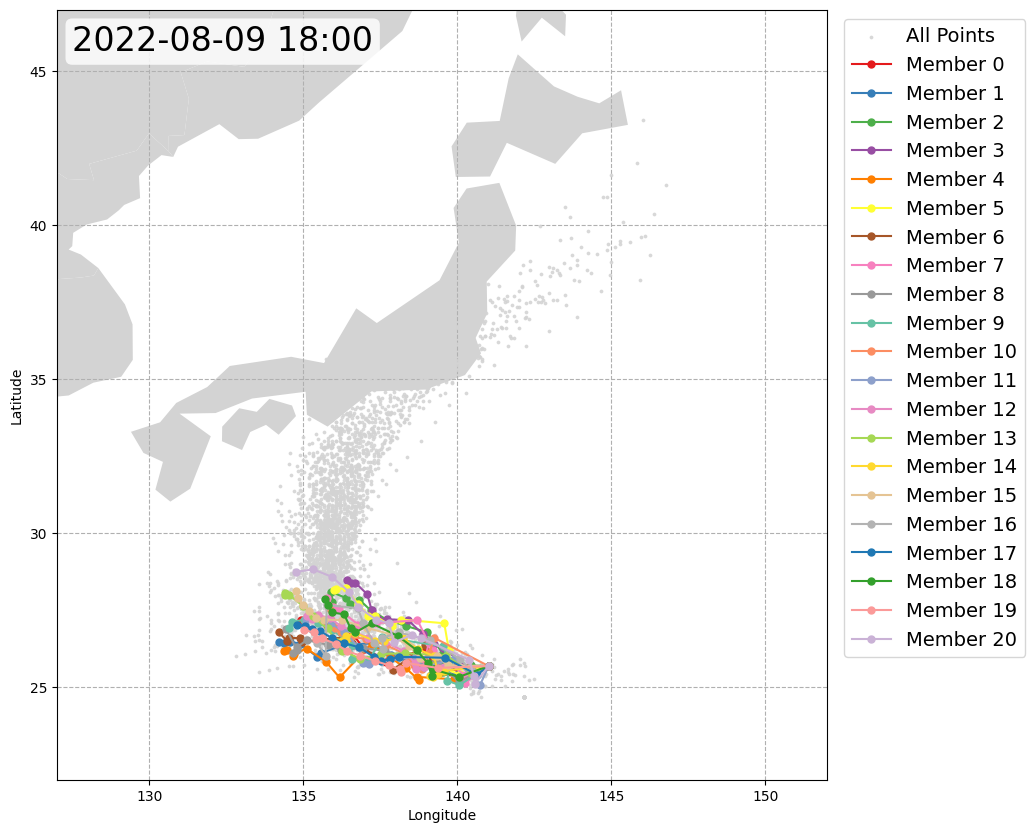

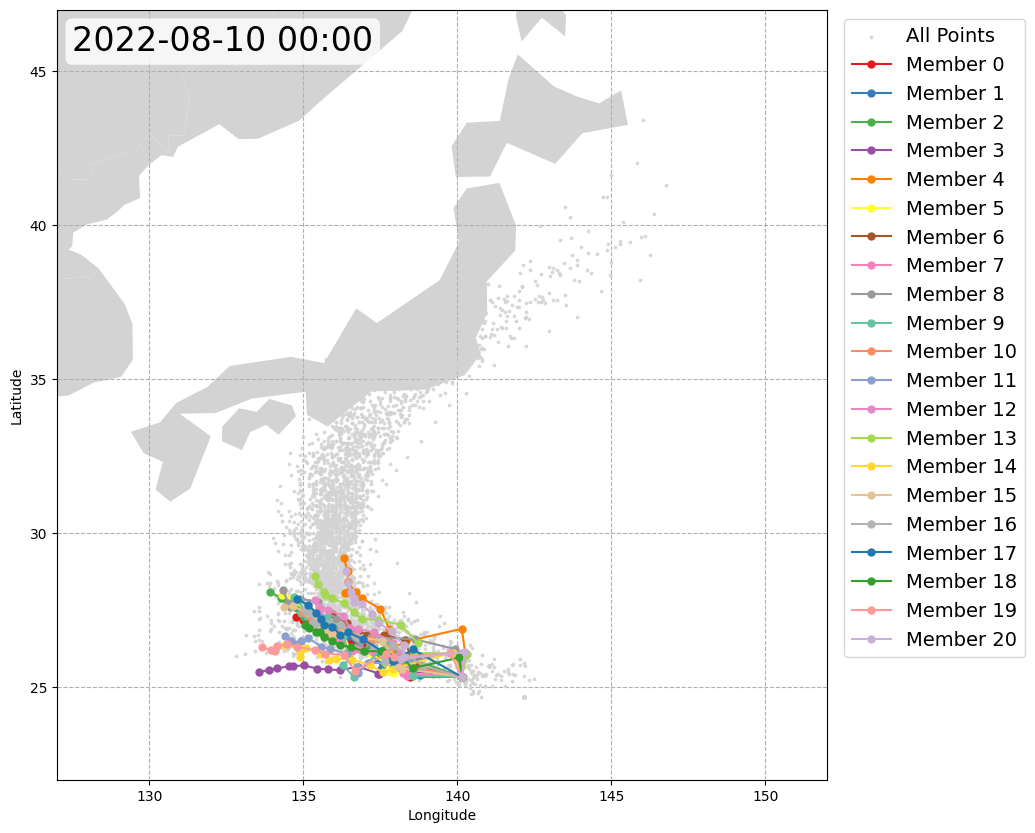

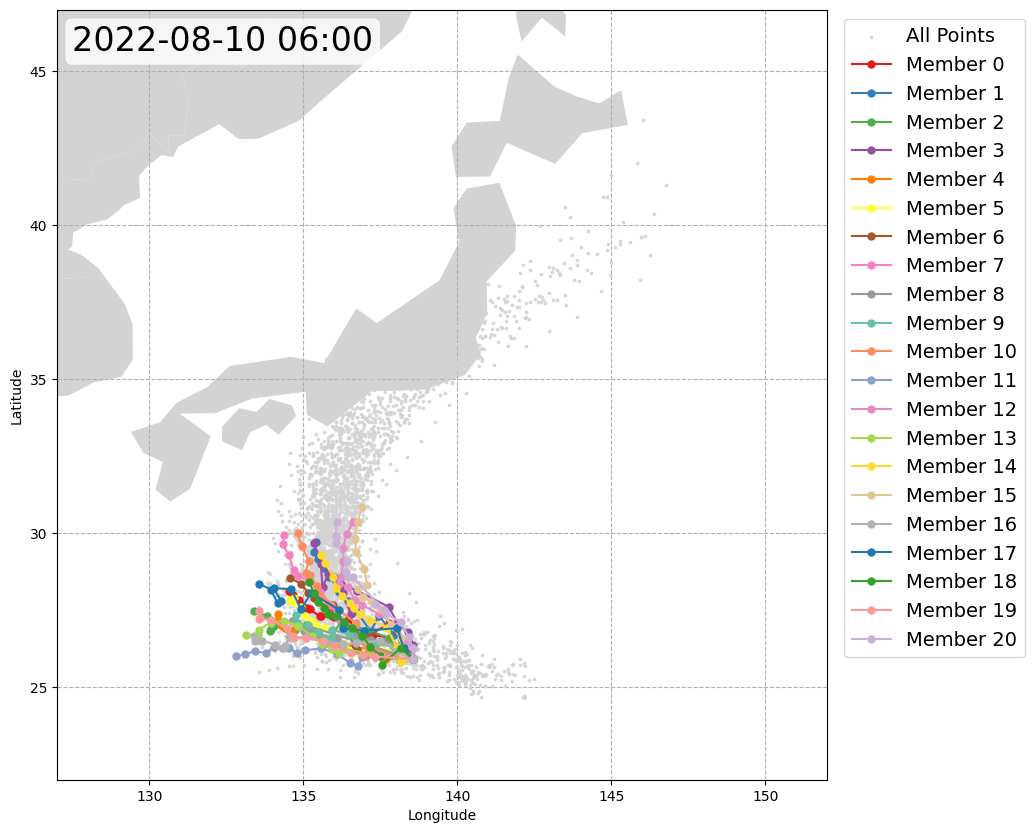

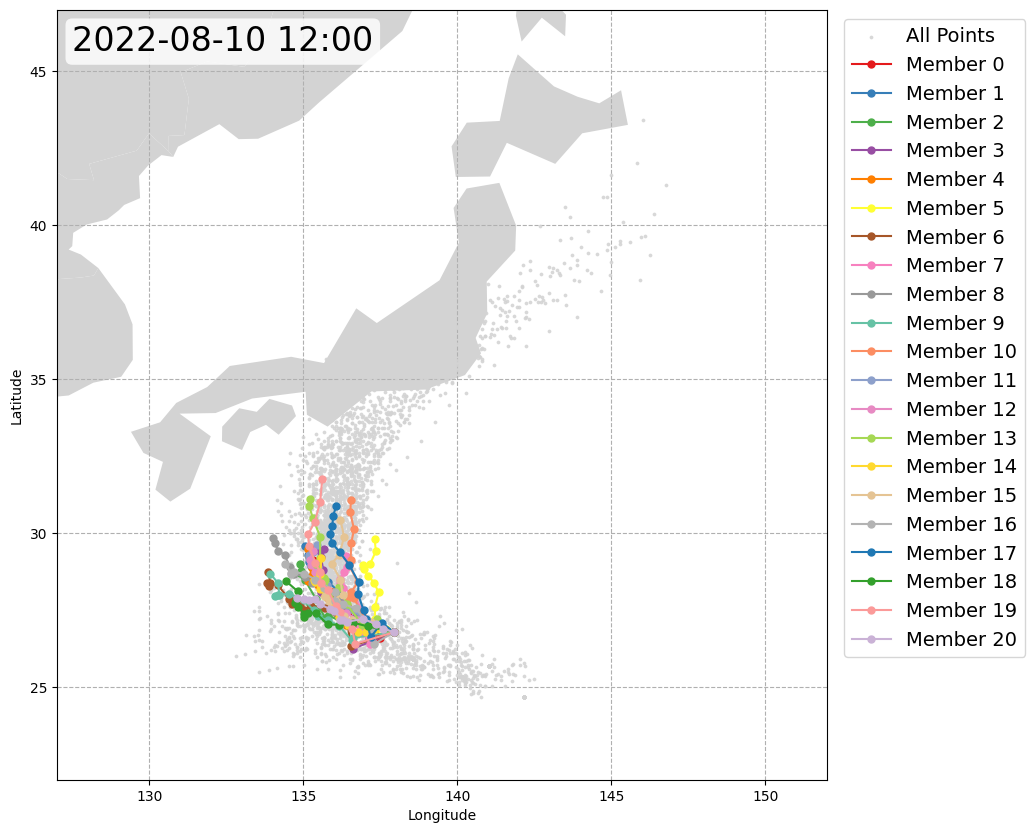

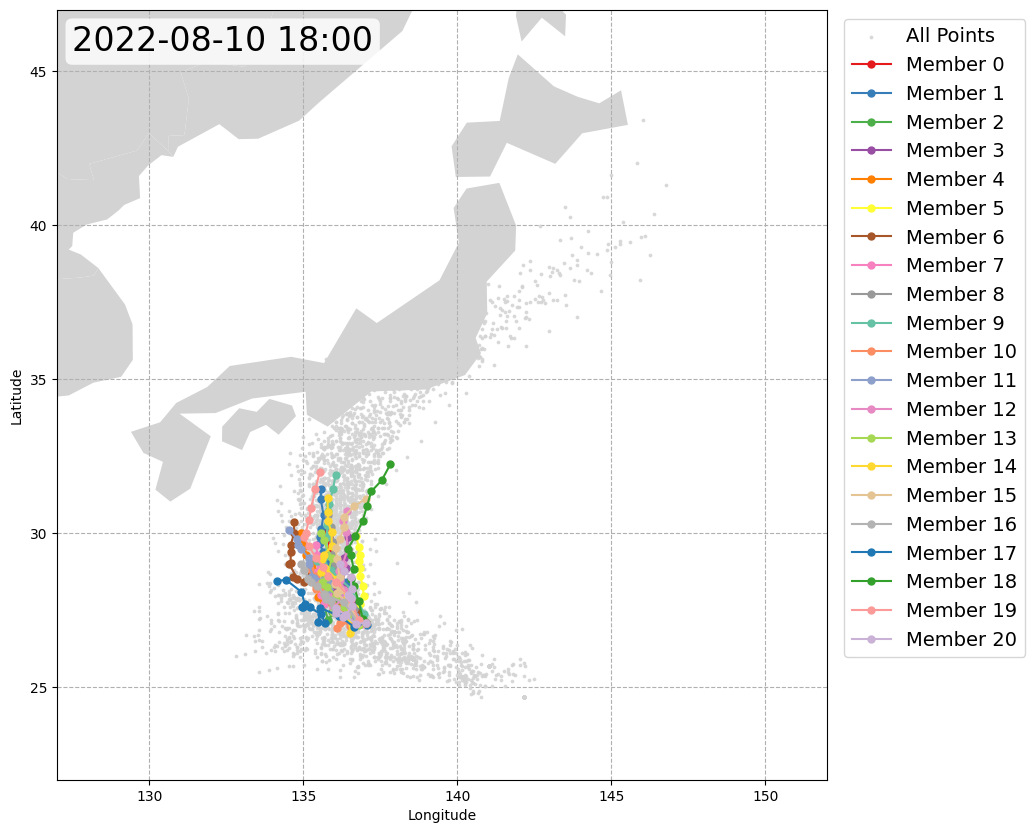

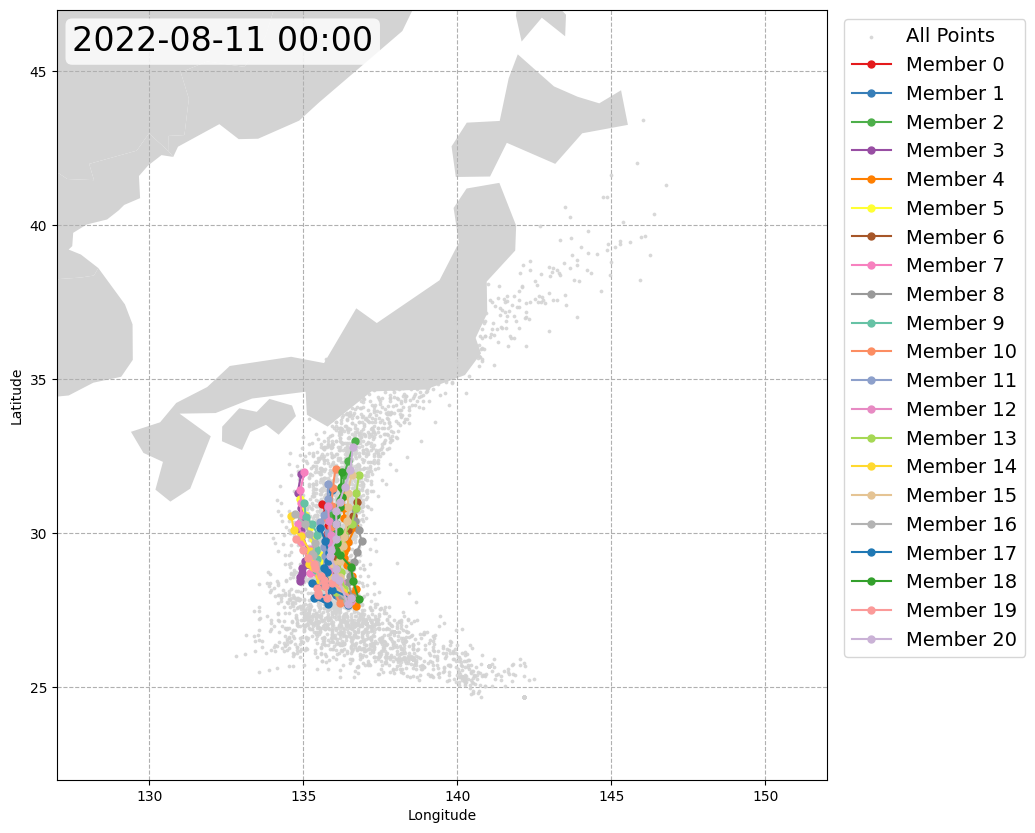

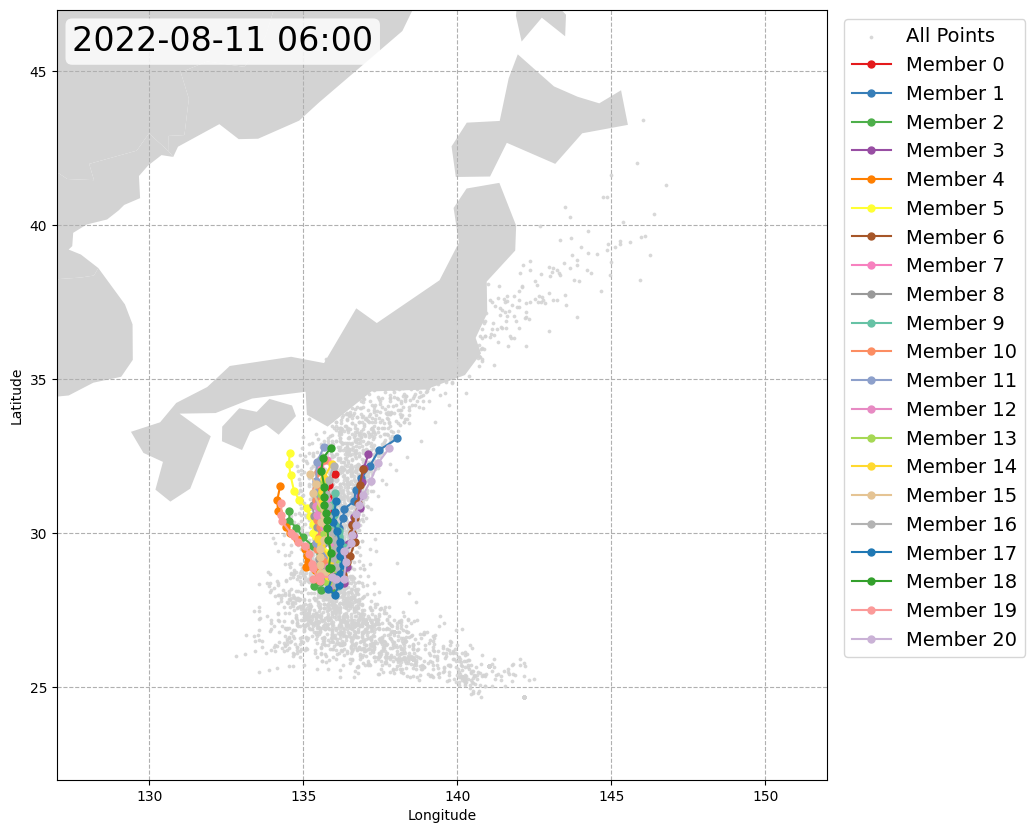

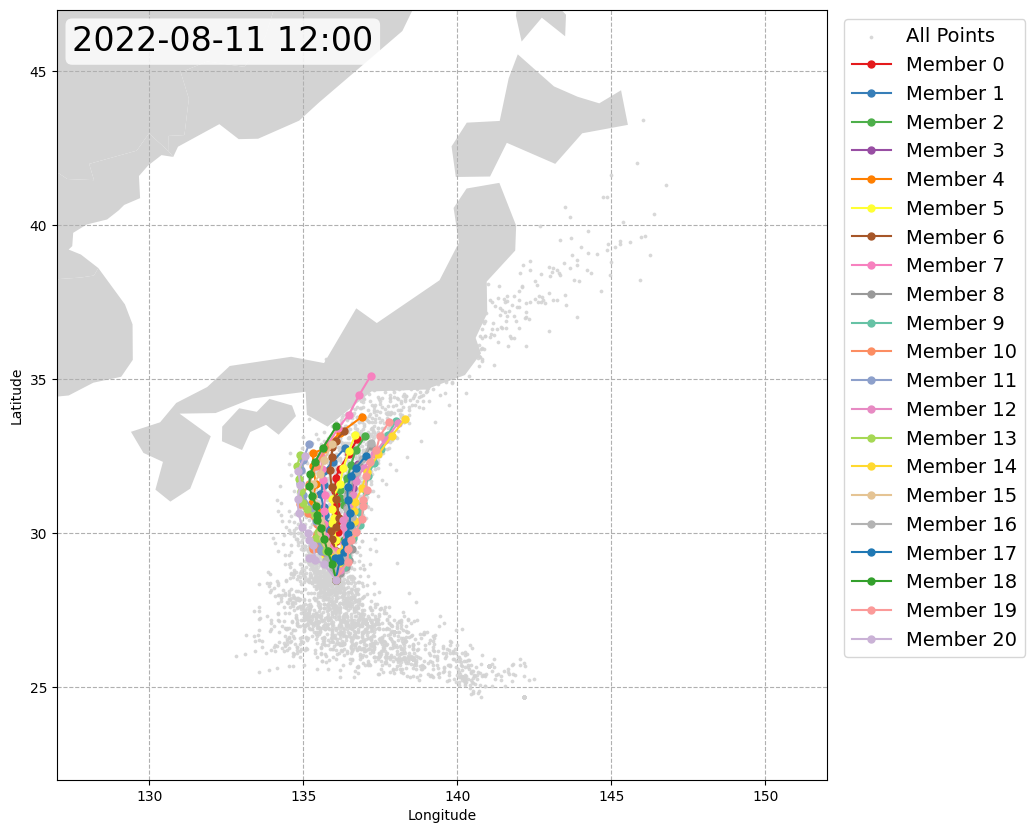

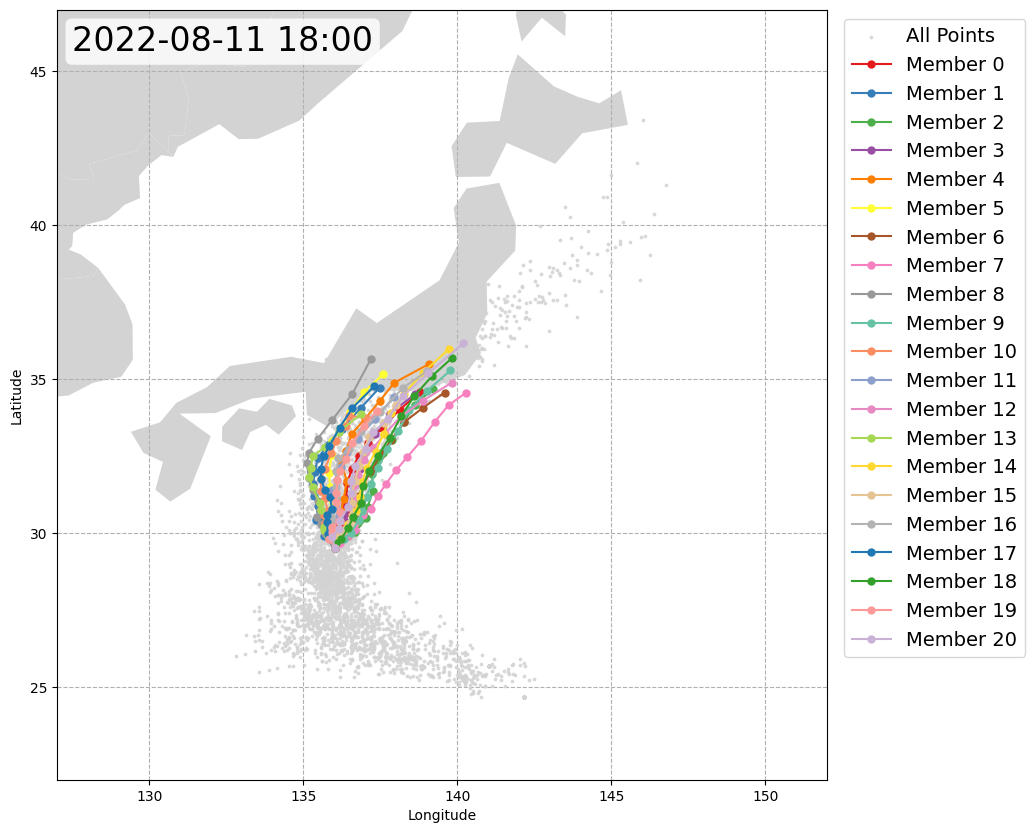

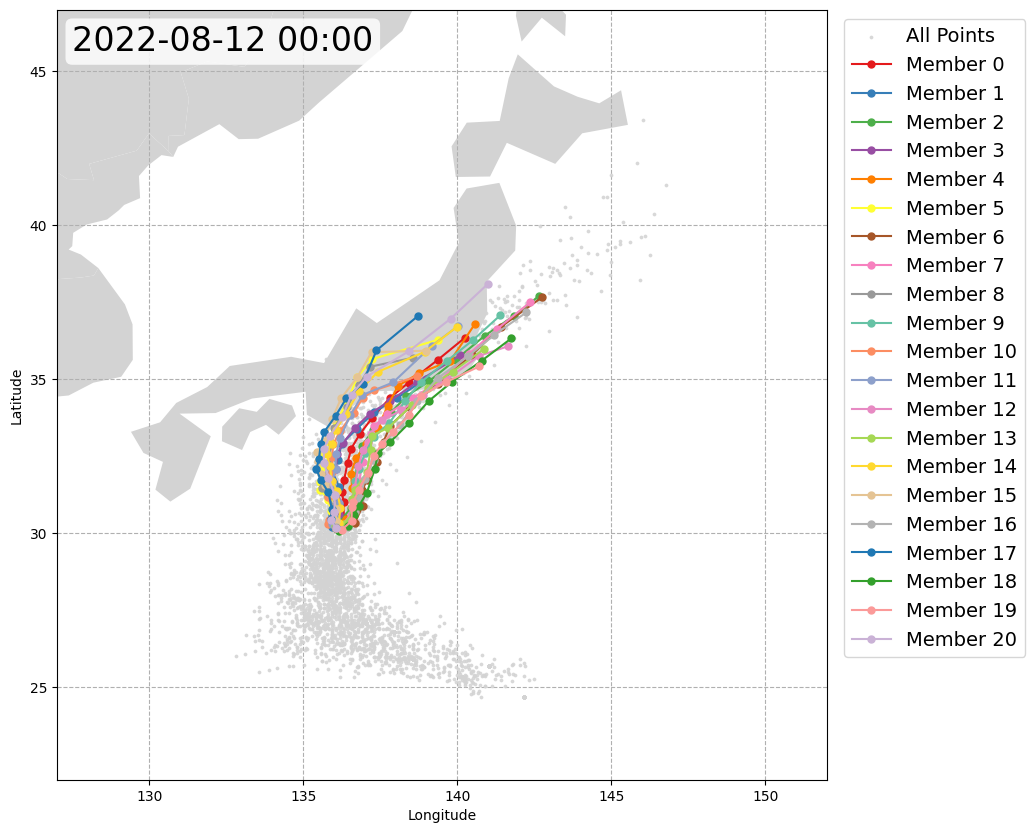

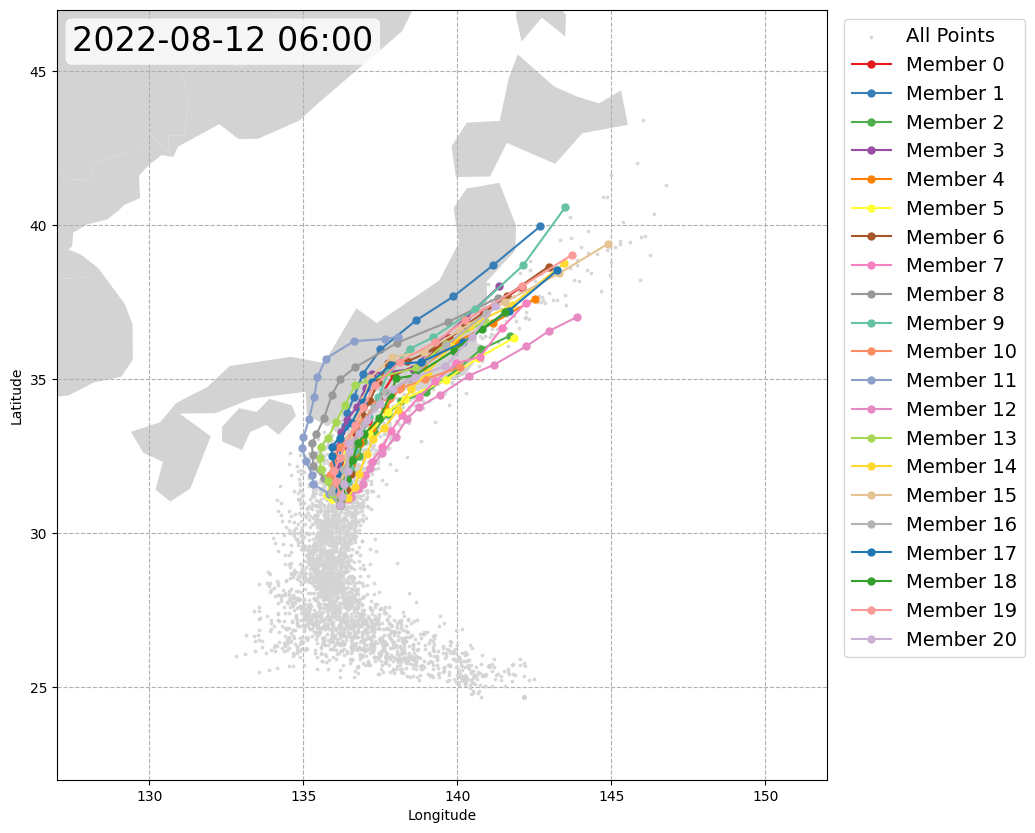

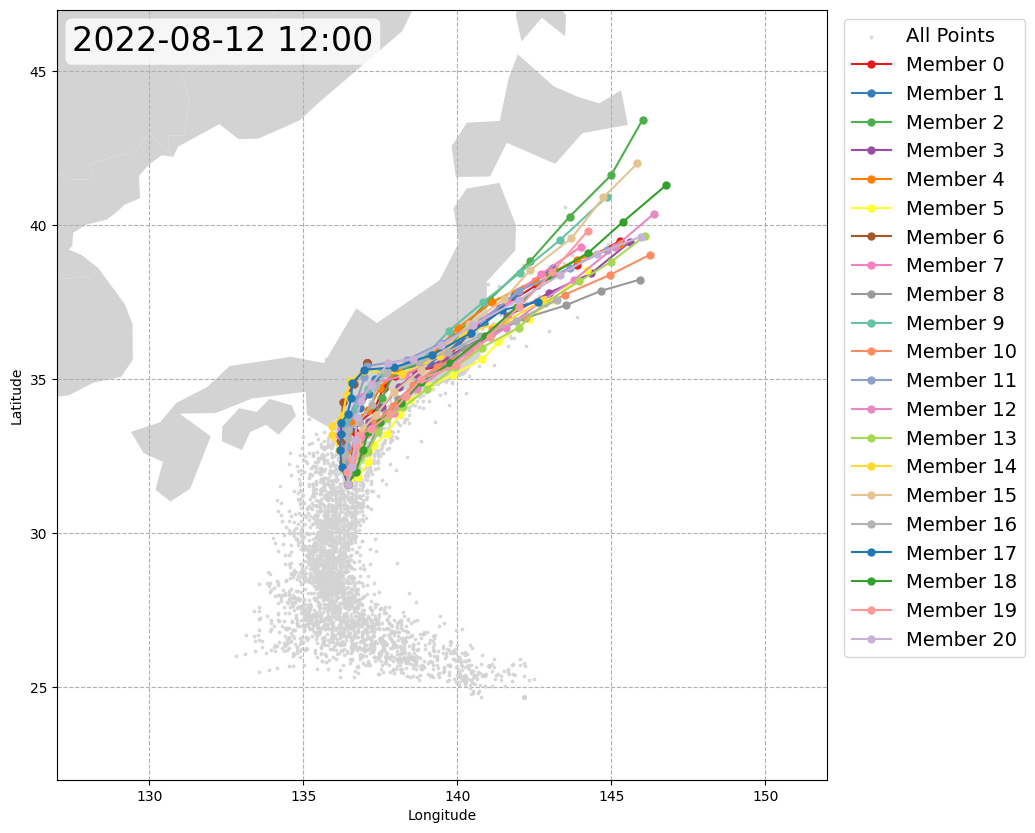

In [11]:
def plot_ensemble_by_init_time(
    adata, long_lim=None, lati_lim=None, background=None, colors=None, show_legend=True,
    show_xlabel=True, show_ylabel=True,
    show_xticklabels=True, show_yticklabels=True,figsize=(10, 10),
    save_fig=False, save_fig_dir="outputs", save_fig_prefix="MEARI_ensemble_"
):
    """
    Plot ensemble tracks for each InitializationTime in adata.obs.

    Parameters
    ----------
    adata : AnnData
        AnnData object with .obs containing 'InitializationTime', 'Member', 'lon', 'lat'.
    long_lim : list or None, optional
        Longitude limits for the plot [min, max].
    lati_lim : list or None, optional
        Latitude limits for the plot [min, max].
    background : GeoDataFrame or None, optional
        GeoDataFrame for background map (e.g., world boundaries).
    colors : list or None, optional
        List of color codes for plotting different members.
    show_legend : bool, default True
        Whether to display the legend.
    show_xlabel : bool, default True
        Whether to display the x-axis label.
    show_ylabel : bool, default True
        Whether to display the y-axis label.
    show_xticklabels : bool, default True
        Whether to display x-axis tick labels.
    show_yticklabels : bool, default True
        Whether to display y-axis tick labels.
    save_fig : bool, default False
        Whether to save the figure.
    save_fig_dir : str, default "outputs"
        Directory to save the figure.
    save_fig_prefix : str, default "MEARI_ensemble_"
        Prefix for the saved figure filename.
    figsize : tuple, default (10, 10)
        Figure size for the plot.

    Returns
    -------
    None
    """
    if colors is None:
        colors = plt.get_cmap('tab20').colors

    unique_init_times = adata.obs['InitializationTime'].unique()
    for init_time in unique_init_times:
        group = adata.obs[adata.obs['InitializationTime'] == init_time]
        fig, ax = plt.subplots(figsize=figsize)
        if background is not None:
            background.plot(ax=ax, color='lightgray', zorder=0)
        plt.scatter(adata.obs['lon'], adata.obs['lat'], color='lightgray', s=3, alpha=0.8, label='All Points', zorder=20)
        for i, member in enumerate(group['Member'].unique()):
            member_group = group[group['Member'] == member].sort_index()
            ax.plot(member_group['lon'], member_group['lat'], marker='o', markersize=5, label=f'Member {member}', zorder=30, color=colors[i % len(colors)])
        ax.text(
            0.02, 0.98, init_time[:-3],
            ha='left', va='top', fontsize=24,
            transform=ax.transAxes,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.2')
        )
        if long_lim is not None:
            ax.set_xlim(long_lim)
        if lati_lim is not None:
            ax.set_ylim(lati_lim)
        if show_xlabel:
            ax.set_xlabel('Longitude')
        if show_ylabel:
            ax.set_ylabel('Latitude')
        ax.grid(ls="--", zorder=10)
        if not show_xticklabels:
            ax.set_xticklabels([])
        if not show_yticklabels:
            ax.set_yticklabels([])
        if show_legend:
            ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=14)
        if save_fig:
            os.makedirs(save_fig_dir, exist_ok=True)
            init_time_modified = init_time.replace(' ', '_').split(':')[0]
            plt.savefig(f"{save_fig_dir}/{save_fig_prefix}{init_time_modified}.png", bbox_inches="tight")
        plt.show()

plot_ensemble_by_init_time(adata, long_lim=[127, 152], lati_lim=[22, 47], background=background, colors=ensamble_colors)

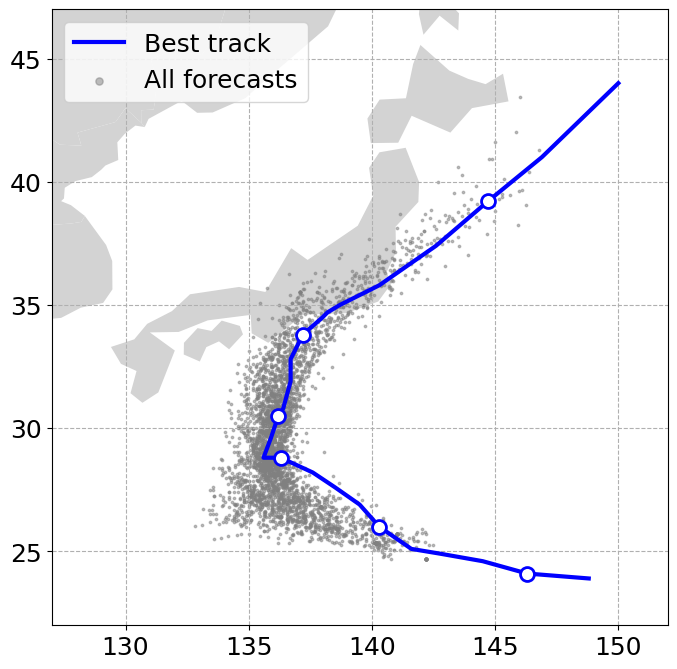

In [12]:
long_lim=[127, 152]
lati_lim=[22, 47]

plt.figure(figsize=(8, 8))
ax = plt.gca()
background.plot(ax=ax, color='lightgray', zorder=0)
ax.plot(best_track_df['lon'], best_track_df['lat'], color='blue', marker='o', markersize=0, label='Best track', zorder=2,lw=3)
ax.scatter(df_input['lon'], df_input['lat'], color='gray', s=3, alpha=0.5, label='All forecasts', zorder=1)
# 日付ラベルを00:00ごとにプロット
for i, dt in enumerate(best_track_df["DateTime"]):
    if "00:00:00" in dt:
        # 日付部分だけ抽出して表示
        date_label = dt.split(" ")[0]
        ax.scatter(best_track_df['lon'].iloc[i], best_track_df['lat'].iloc[i], edgecolor='blue', facecolor="w", marker='o', zorder=10, s=100, linewidths=2)
ax.set_xlim(long_lim)
ax.set_ylim(lati_lim)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.legend(fontsize=18, markerscale=3)
plt.grid(ls="--")
# plt.savefig(f"{OUTPUT_DIR}/MEARI_best_track.png", bbox_inches="tight")
plt.show()


# Numerical experiments with whole ensamble weather forecasted data

## K-means clustering

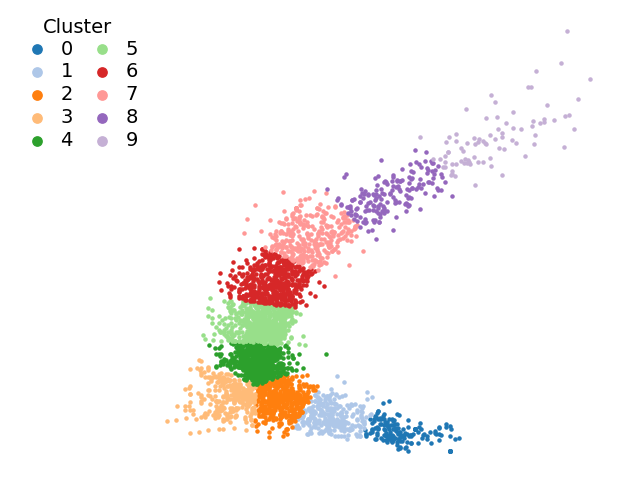

In [ ]:
n_clusters = 10

kmeans = KMeans(n_clusters=n_clusters, random_state=0)
adata.obs['cluster'] = kmeans.fit_predict(adata.X)

cluster_means = adata.obs.groupby('cluster')['lat'].mean().sort_values()
cluster_map = {old: new for new, old in enumerate(cluster_means.index)}
adata.obs['cluster'] = adata.obs['cluster'].map(cluster_map)

plt.figure(figsize=(6, 6))
cmap = plt.get_cmap('tab20')
for cluster_id in sorted(adata.obs['cluster'].unique()):
    mask = adata.obs['cluster'] == cluster_id
    plt.scatter(adata.X[mask, 0], adata.X[mask, 1],
                s=5, c=[cmap(cluster_id % 20)], label=f'{cluster_id}')
legend = plt.legend(
    title='Cluster',
    bbox_to_anchor=(0.0, 1),
    loc='upper right',
    borderaxespad=0.,
    ncol=2,
    markerscale=3,
    frameon=False,
    fontsize=14,
    title_fontsize=14,  # タイトルのフォントサイズを大きく
    handletextpad=0.2,   # マーカーとテキストの間隔を狭く
    columnspacing=0.5,    # 列間のスペースを狭く
    labelspacing=0.2,
)
legend._legend_box.sep = 2 
plt.axis("off")
# plt.savefig(f"{OUTPUT_DIR}/MEARI_clusters.png", bbox_inches="tight")
plt.show()

In [ ]:
good_cluster_key = 3
bad_cluster_key = 9

## Compute $\varepsilon$- and $\varepsilon_\Sigma$-attracting basin

In [ ]:
epsbasin.eps_attracting_basin(adata, target_cluster_key=good_cluster_key)
epsbasin.eps_attracting_basin(adata, target_cluster_key=bad_cluster_key)
epsbasin.eps_sum_attracting_basin(adata, target_cluster_key=good_cluster_key)
epsbasin.eps_sum_attracting_basin(adata, target_cluster_key=bad_cluster_key)

## Sublevel set visualization of $\varepsilon$- and $\varepsilon_\Sigma$-attracting basin

/home/imoto-lab-dell2022/personal/fujiwara/epsbasin/epsbasin.py:116: SyntaxWarning: invalid escape sequence '\S'
  """
/home/imoto-lab-dell2022/personal/fujiwara/epsbasin/epsbasin.py:240: SyntaxWarning: invalid escape sequence '\S'
  """


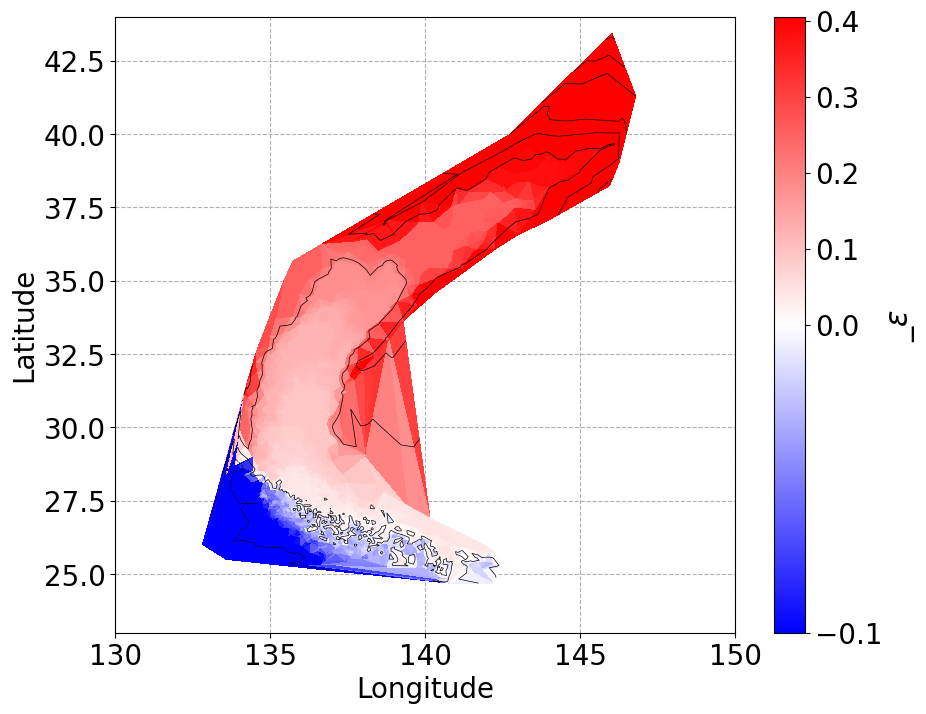

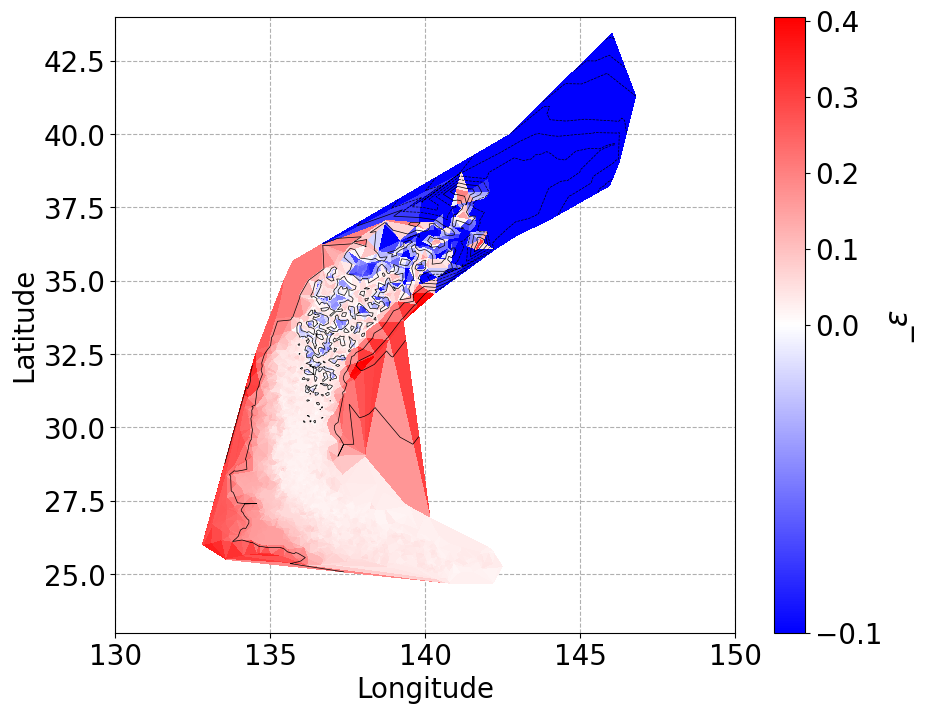

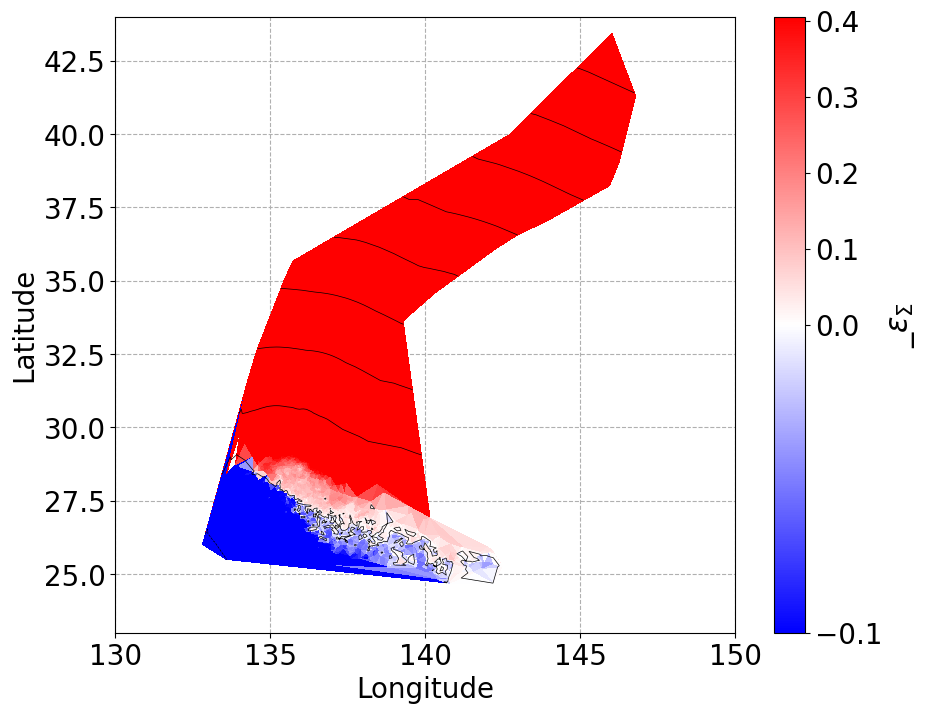

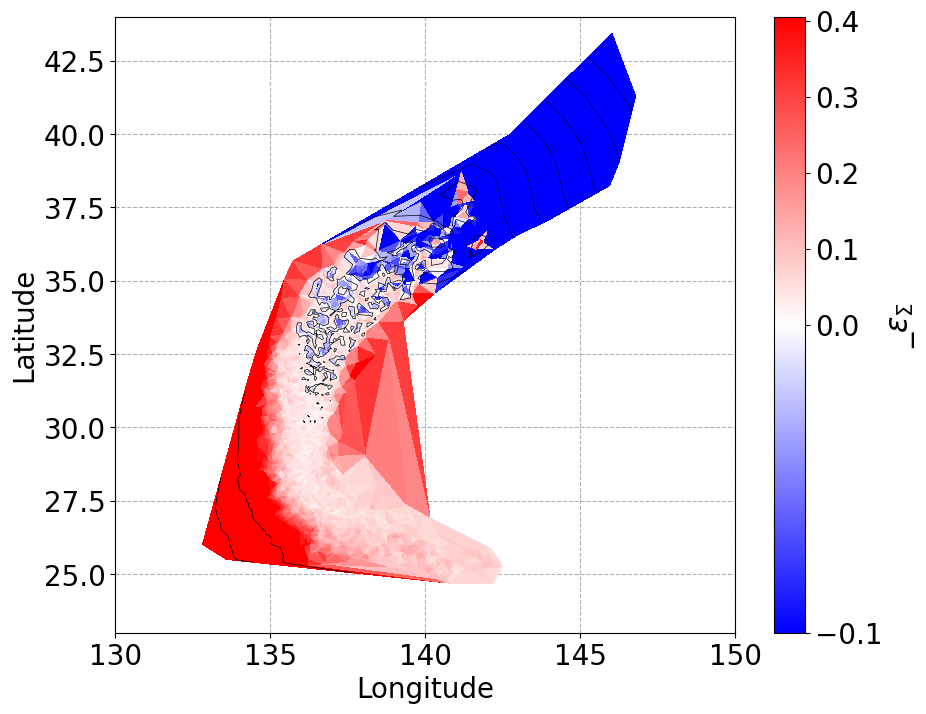

In [ ]:
import importlib
importlib.reload(epsbasin)
epsbasin.sublevel_set_visualization(adata, eps_key="eps_attracting_basin", 
                           target_cluster_key=good_cluster_key,
                           color_name="_$\\varepsilon$",
                           xlim=[130, 150],ylim=[23, 44],
                           xlabel="Longitude", ylabel="Latitude",
                           vmin=-0.1, vmax=0.405)
epsbasin.sublevel_set_visualization(adata, eps_key="eps_attracting_basin", 
                           target_cluster_key=bad_cluster_key,
                           color_name="_$\\varepsilon$",
                           xlim=[130, 150],ylim=[23, 44],
                           xlabel="Longitude", ylabel="Latitude",
                           vmin=-0.1, vmax=0.405)

epsbasin.sublevel_set_visualization(adata, eps_key="eps_sum_attracting_basin", 
                           target_cluster_key=good_cluster_key,
                           color_name="_$\\varepsilon_\\Sigma$",
                           xlim=[130, 150],ylim=[23, 44],
                           xlabel="Longitude", ylabel="Latitude",
                           vmin=-0.1, vmax=0.405)
epsbasin.sublevel_set_visualization(adata, eps_key="eps_sum_attracting_basin", 
                           target_cluster_key=bad_cluster_key,
                           color_name="_$\\varepsilon_\\Sigma$",
                           xlim=[130, 150],ylim=[23, 44],
                           xlabel="Longitude", ylabel="Latitude",
                           vmin=-0.1, vmax=0.405)

## Plot debut functions $\underline\varepsilon$ and $\underline\varepsilon_\Sigma$ on the best track

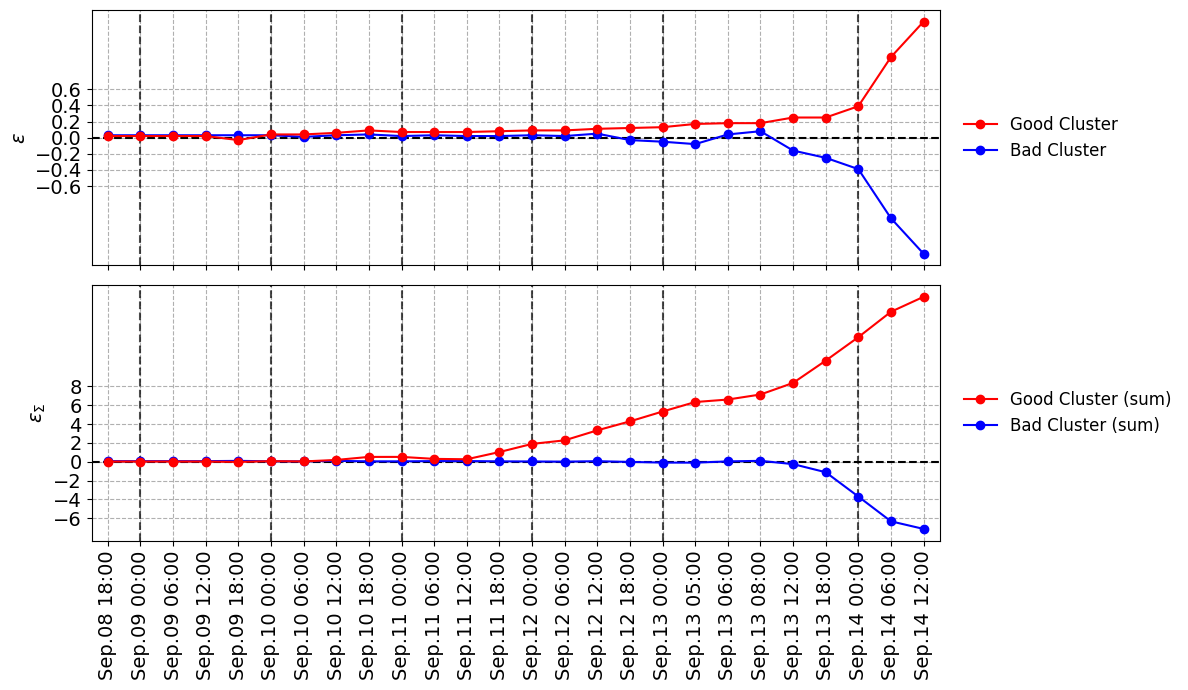

In [ ]:
def plot_best_track_eps(
    best_track_df, adata, 
    eps_key="eps_attracting_basin", eps_sum_key="eps_sum_attracting_basin",
    good_cluster_key=None, bad_cluster_key=None, 
    figsize=(12, 7), xticks=True, yticks=True, show_legend=True, output_path=None,
    xticklabels=True, yticklabels=True, ylabel=True
):
    """
    Plot the values of eps and eps_sum for the best track points, for both good and bad clusters.

    Parameters:
        best_track_df (pd.DataFrame): DataFrame containing the best track with columns ['lon', 'lat', 'time'].
        adata (anndata.AnnData): AnnData object containing forecast points and cluster info.
        eps_key (str): Key for epsilon-attracting basin in adata.obs.
        eps_sum_key (str): Key for epsilon-sum-attracting basin in adata.obs.
        good_cluster_key (int or str): Cluster id or name for the good cluster.
        bad_cluster_key (int or str): Cluster id or name for the bad cluster.
        figsize (tuple): Figure size for the plot.
        xticks (bool): Whether to show x-tick labels.
        yticks (bool): Whether to show y-tick labels.
        xticklabels (bool): Whether to show x-tick labels (string).
        yticklabels (bool): Whether to show y-tick labels (string).
        output_path (str): Path to save the output plot.
        show_legend (bool): Whether to show the legend.
    """
    import matplotlib.pyplot as plt

    # Use adata.X as forecast points
    df_points = adata.X

    # Find nearest forecast point for each best track point
    tree = cKDTree(df_points)
    distances, indices = tree.query(best_track_df[['lon', 'lat']].values)

    # Get eps and eps_sum for good/bad clusters
    if good_cluster_key is None or bad_cluster_key is None:
        raise ValueError("good_cluster_key and bad_cluster_key must be specified.")

    best_track_eps_good = adata.obs[f"{eps_key}_{good_cluster_key}"].values[indices]
    best_track_eps_bad = adata.obs[f"{eps_key}_{bad_cluster_key}"].values[indices]
    best_track_eps_sum_good = adata.obs[f"{eps_sum_key}_{good_cluster_key}"].values[indices]
    best_track_eps_sum_bad = adata.obs[f"{eps_sum_key}_{bad_cluster_key}"].values[indices]

    # Format x-axis labels
    plot_x = ["Sep."+str(s)[8:10]+" "+str(s)[11:16] for s in best_track_df['time'].values]

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    # eps plot
    axes[0].plot(plot_x, best_track_eps_good, c="r", marker='o', label='Good Cluster', zorder=30)
    axes[0].plot(plot_x, best_track_eps_bad, c="b", marker='o', label='Bad Cluster', zorder=20)
    for i, label in enumerate(plot_x):
        if label.endswith("00:00"):
            axes[0].axvline(x=i, color="k", ls="--", linewidth=1.5, alpha=0.7, zorder=10)
    axes[0].axhline(0, c="k", ls="--", zorder=5)
    axes[0].grid(ls="--", zorder=0)
    if ylabel:
        axes[0].set_ylabel(r"$\varepsilon$", fontsize=14)
    if not yticks:
        axes[0].set_yticks([])
    if not yticklabels:
        axes[0].set_yticklabels([])
    if show_legend:
        axes[0].legend(
            fontsize=12,
            bbox_to_anchor=(1.02, 0.5),
            loc='center left',
            borderaxespad=0.,
            frameon=False,
        )

    # eps_sum plot
    axes[1].plot(plot_x, best_track_eps_sum_good, c="r", marker='o', label='Good Cluster (sum)', linestyle='-', zorder=30)
    axes[1].plot(plot_x, best_track_eps_sum_bad, c="b", marker='o', label='Bad Cluster (sum)', linestyle='-', zorder=20)
    for i, label in enumerate(plot_x):
        if label.endswith("00:00"):
            axes[1].axvline(x=i, color="k", ls="--", linewidth=1.5, alpha=0.7, zorder=10)
    axes[1].axhline(0, c="k", ls="--", zorder=5)
    axes[1].grid(ls="--", zorder=0)
    if ylabel:
        axes[1].set_ylabel(r"$\varepsilon_\Sigma$", fontsize=14)
    if not yticks:
        axes[1].set_yticks([])
    if not yticklabels:
        axes[1].set_yticklabels([])
    if show_legend:
        axes[1].legend(
            fontsize=12,
            bbox_to_anchor=(1.02, 0.5),
            loc='center left',
            borderaxespad=0.,
            frameon=False,
        )
    axes[0].set_yticks(np.arange(-0.6, 0.8, 0.2))  
    axes[1].set_yticks(np.arange(-6, 10, 2))  
    axes[1].set_xticks(range(len(plot_x)))
    if xticklabels:
        axes[1].set_xticklabels(plot_x, rotation=90, fontsize=14)
    else:
        axes[1].set_xticklabels([])
    axes[1].set_xlim(-0.5, len(plot_x) - 0.5)
    axes[0].tick_params(axis='y', labelsize=14)
    axes[1].tick_params(axis='y', labelsize=14)
    if not xticks:
        axes[1].set_xticks([])
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, bbox_inches="tight")
    plt.show()

plot_best_track_eps(best_track_df, adata, good_cluster_key=good_cluster_key, 
                    bad_cluster_key=bad_cluster_key)

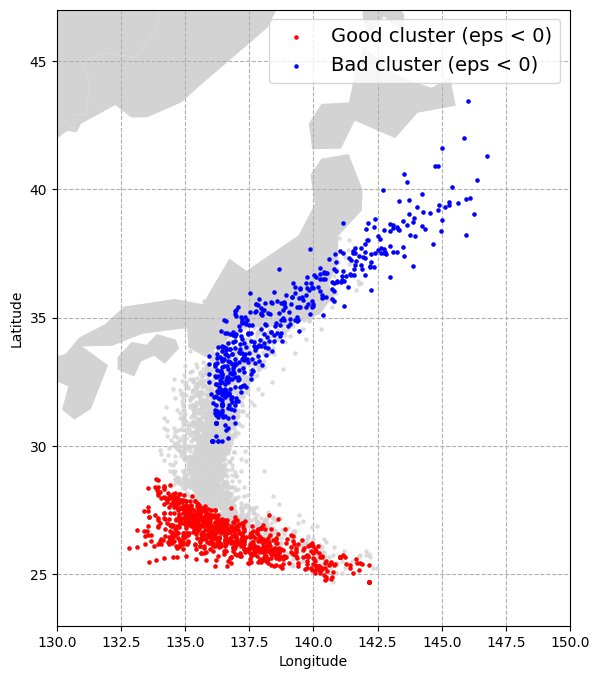

In [ ]:
eps_key="eps_attracting_basin"
ps = 5
plt.figure(figsize=(8, 8))
ax = plt.gca()
background.plot(ax=ax, color='lightgray', zorder=0)

# 全点を薄いグレーで描画
ax.scatter(df_input['lon'], df_input['lat'], color='lightgray', s=ps, alpha=0.7, zorder=5)

# eps[good_cluster] < 0 の点を赤で強調
mask_good_neg = adata.obs[f"{eps_key}_{good_cluster_key}"] < 0
ax.scatter(adata.X[mask_good_neg, 0], adata.X[mask_good_neg, 1],
           color='red', s=ps, label='Good cluster (eps < 0)', zorder=10)

# eps[bad_cluster] < 0 の点を青で強調
mask_bad_neg = adata.obs[f"{eps_key}_{bad_cluster_key}"] < 0
ax.scatter(adata.X[mask_bad_neg, 0], adata.X[mask_bad_neg, 1],
           color='blue', s=ps, label='Bad cluster (eps < 0)', zorder=10)

ax.set_xlim([130,150])
ax.set_ylim([23,47])
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(ls="--", zorder=0)
ax.legend(fontsize=14)
plt.show()

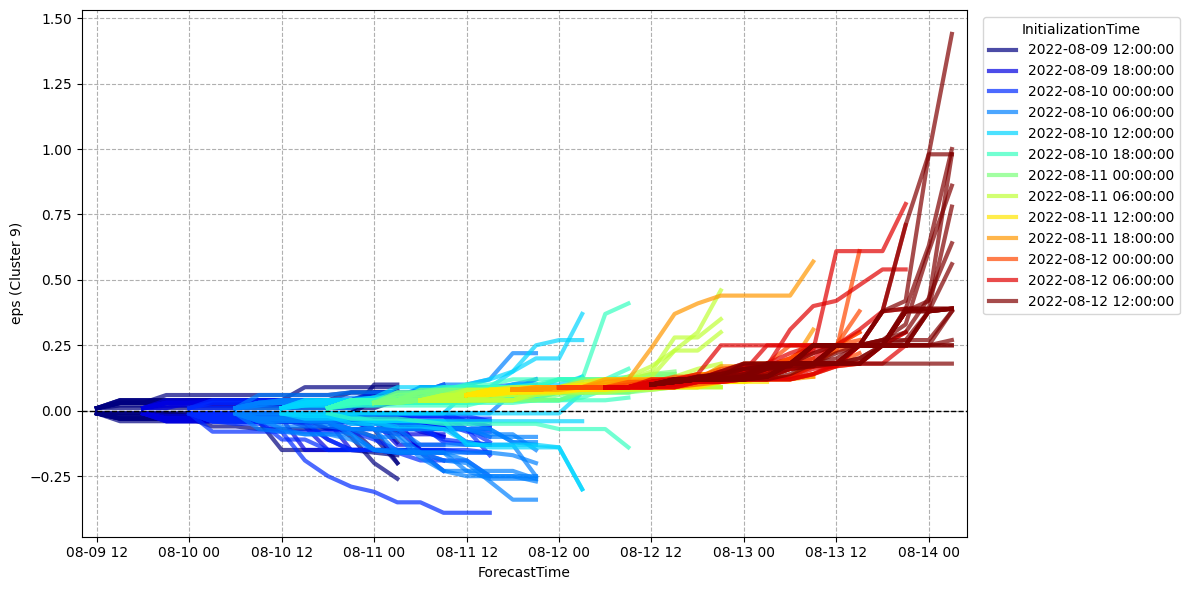

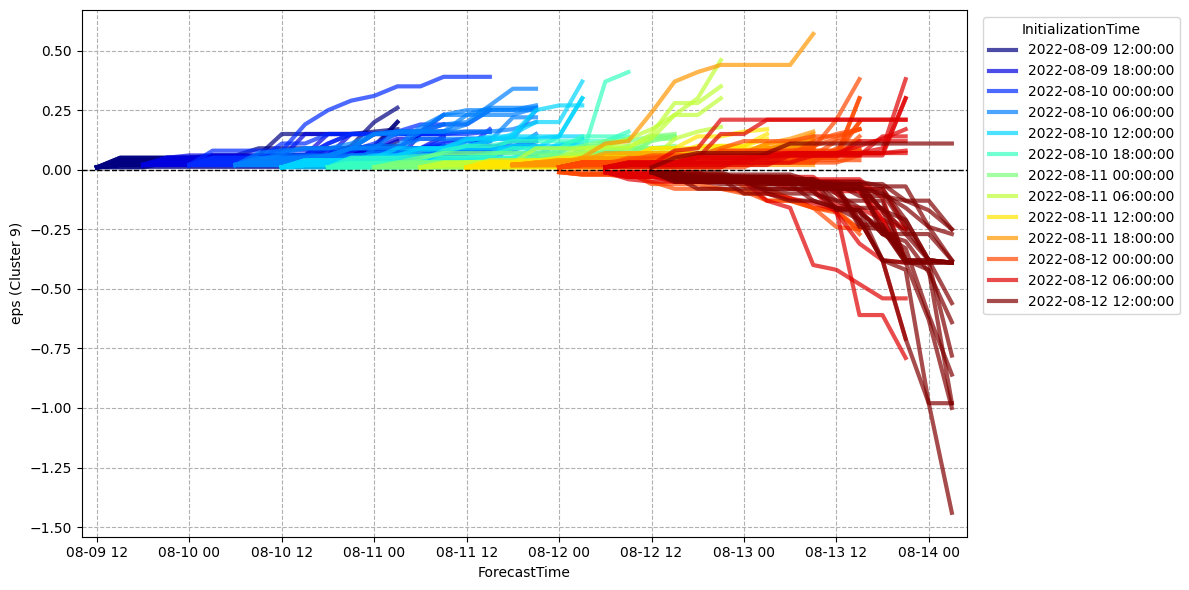

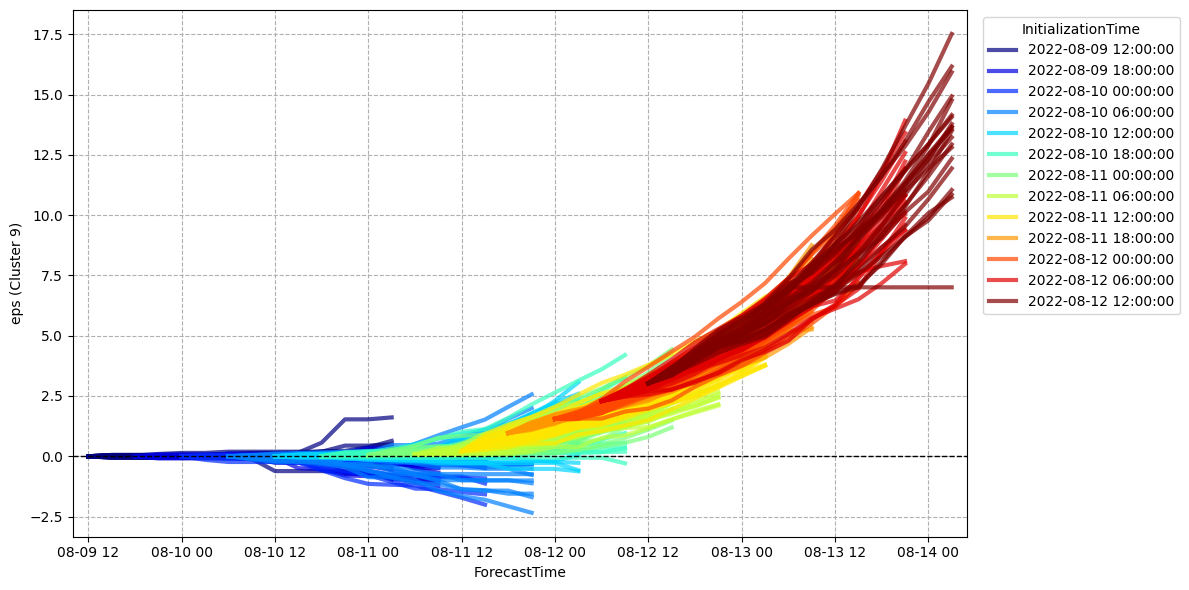

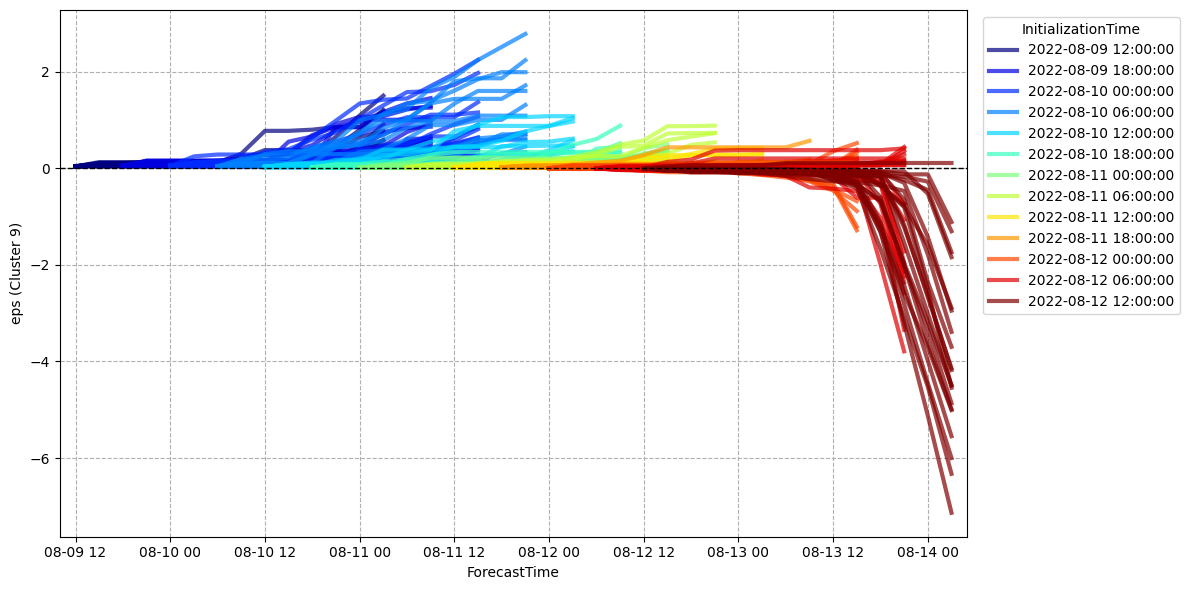

In [ ]:

def plot_eps_time_series(adata, eps_key="eps_attracting_basin", target_cluster_key="target", figsize=(12, 6)):
    """
    Plot time series of eps for all InitializationTime and Member combinations for a given cluster.

    Parameters:
        df_input (pd.DataFrame): Input dataframe with columns ['InitializationTime', 'Member', 'ForecastTime'].
        eps (dict): Dictionary of eps arrays for each cluster.
        cluster_id (int): Cluster id to plot.
        figsize (tuple): Figure size for the plot.
    """
    plt.figure(figsize=figsize)
    ax = plt.gca()

    init_times = sorted(df_input['InitializationTime'].unique())
    cmap = plt.get_cmap('jet', len(init_times))
    init_time_colors = {t: cmap(i) for i, t in enumerate(init_times)}

    all_times = []
    for (init_time, member), group in df_input.groupby(['InitializationTime', 'Member']):
        times = pd.to_datetime(group['ForecastTime'])
        idx = group.index
        eps_vals = adata.obs[f"{eps_key}_{target_cluster_key}"].values[idx]
        ax.plot(times, eps_vals, color=init_time_colors[init_time], alpha=0.7, lw=3, label=init_time if member == 0 else "")
        all_times.extend(times)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10, ncol=1, title="InitializationTime")

    ax.axhline(0, color='k', ls='--', lw=1)
    ax.set_xlabel('ForecastTime')
    ax.set_ylabel(f'eps (Cluster {cluster_id})')
    ax.grid(ls='--')

    if all_times:
        ax.set_xlim(min(all_times) - pd.Timedelta(hours=2), max(all_times) + pd.Timedelta(hours=2))

    plt.tight_layout()
    plt.show()

plot_eps_time_series(adata, eps_key="eps_attracting_basin", target_cluster_key=good_cluster_key)
plot_eps_time_series(adata, eps_key="eps_attracting_basin", target_cluster_key=bad_cluster_key)
plot_eps_time_series(adata, eps_key="eps_sum_attracting_basin", target_cluster_key=good_cluster_key)
plot_eps_time_series(adata, eps_key="eps_sum_attracting_basin", target_cluster_key=bad_cluster_key)